Group Project: Matthew Peters, Ruby Mayrose, Xingyu Liu

# Part 2:

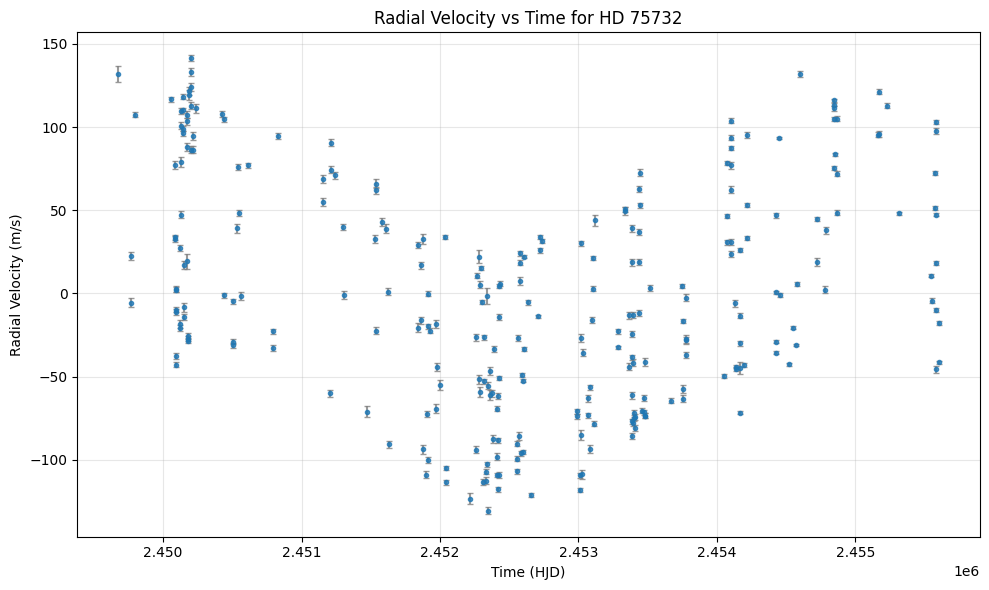

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii

# Load the data table
data = ascii.read("RadialVelocity.txt")

# Extract columns
time = data["HJD"]
rv = data["Radial_Velocity"]
rv_err = data["Radial_Velocity_Uncertainty"]

# Make plot
plt.figure(figsize=(10,6))
plt.errorbar(time, rv, yerr=rv_err, fmt='o', markersize=3, 
             ecolor='gray', capsize=2, alpha=0.8)

plt.xlabel("Time (HJD)")
plt.ylabel("Radial Velocity (m/s)")
plt.title("Radial Velocity vs Time for HD 75732")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Part 3:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
from scipy import optimize

In [3]:
data = ascii.read("RadialVelocity.txt")

time = data["HJD"]
rv = data["Radial_Velocity"]
rv_err = data["Radial_Velocity_Uncertainty"]

In [4]:
def rv_model(t, a, b, c, d):
    return a * np.sin(2*np.pi*(t - b)/c) + d

In [5]:
guess_params = [100, 0, 3000, 0]  # amplitude, phase, period, offset

In [6]:
best_params, covariance = optimize.curve_fit(
    rv_model, time, rv, p0=guess_params, sigma=rv_err, absolute_sigma=True
)

best_a, best_b, best_c, best_d = best_params

print("Best-fit parameters:")
print("Amplitude =", best_a)
print("Phase shift =", best_b)
print("Period =", best_c)
print("Mean RV =", best_d)

Best-fit parameters:
Amplitude = 47.91814842467463
Phase shift = -1478158.6052357587
Period = 4806.915133562828
Mean RV = -1.418465396827657


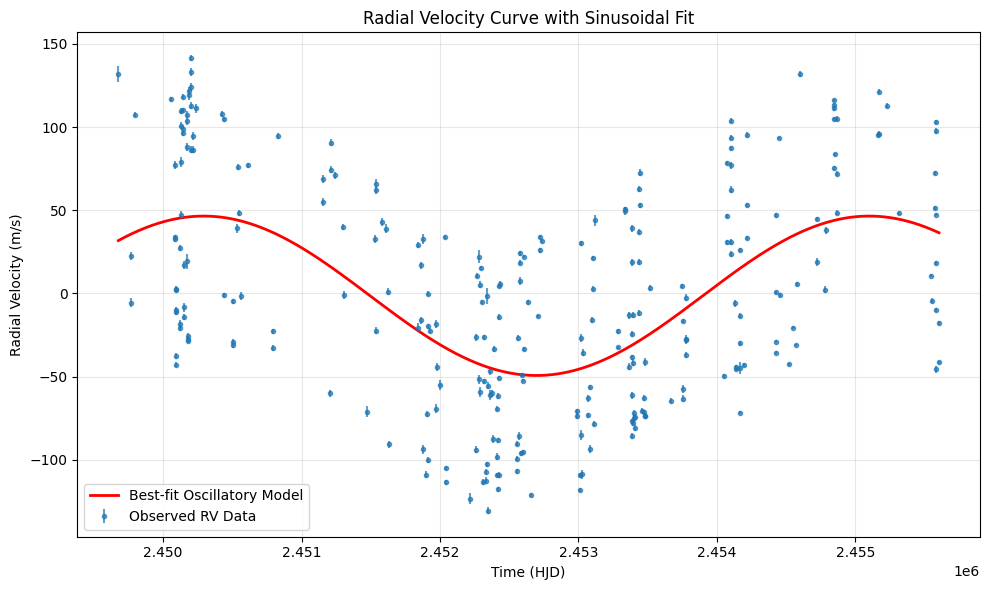

In [7]:
t_fit = np.linspace(min(time), max(time), 1000)
rv_fit = rv_model(t_fit, best_a, best_b, best_c, best_d)

plt.figure(figsize=(10,6))
plt.errorbar(time, rv, yerr=rv_err, fmt='o', markersize=3, 
             alpha=0.7, label="Observed RV Data")

plt.plot(t_fit, rv_fit, 'r-', linewidth=2, label="Best-fit Oscillatory Model")

plt.xlabel("Time (HJD)")
plt.ylabel("Radial Velocity (m/s)")
plt.title("Radial Velocity Curve with Sinusoidal Fit")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Part 4:

Best-fit parameters:
Amplitude = 47.91814842467463
Phase shift = -1478158.6052357587
Period = 4806.915133562828
Mean RV = -1.418465396827657


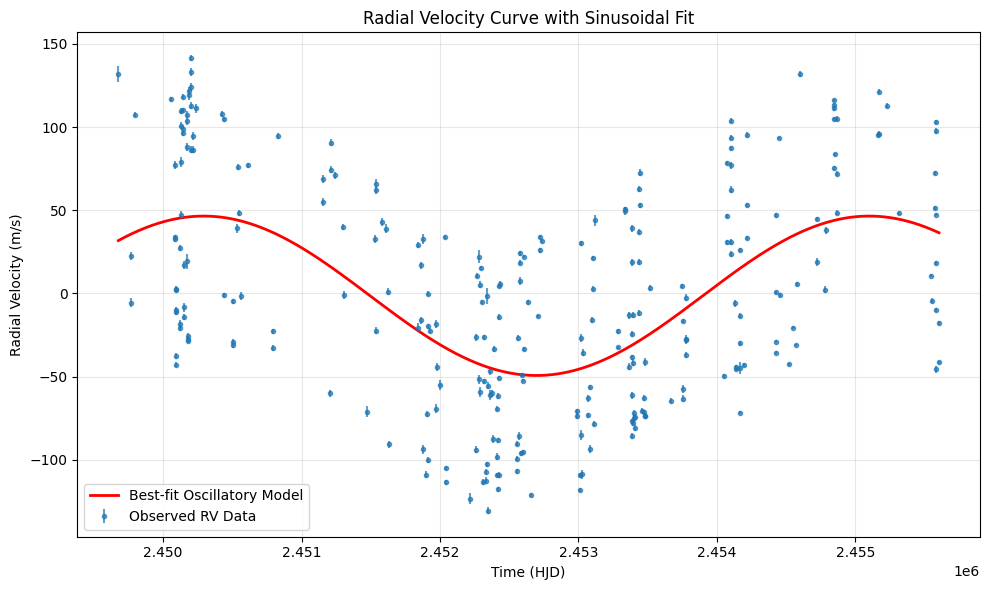

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
from scipy import optimize

data = ascii.read("RadialVelocity.txt")

time = data["HJD"]
rv = data["Radial_Velocity"]
rv_err = data["Radial_Velocity_Uncertainty"]

def rv_model(t, a, b, c, d):
    return a * np.sin(2*np.pi*(t - b)/c) + d

guess_params = [100, 0, 3000, 0]  # amplitude, phase, period, offset

best_params, covariance = optimize.curve_fit(
    rv_model, time, rv, p0=guess_params, sigma=rv_err, absolute_sigma=True
)

best_a, best_b, best_c, best_d = best_params

print("Best-fit parameters:")
print("Amplitude =", best_a)
print("Phase shift =", best_b)
print("Period =", best_c)
print("Mean RV =", best_d)

t_fit = np.linspace(min(time), max(time), 1000)
rv_fit = rv_model(t_fit, best_a, best_b, best_c, best_d)

plt.figure(figsize=(10,6))
plt.errorbar(time, rv, yerr=rv_err, fmt='o', markersize=3, 
             alpha=0.7, label="Observed RV Data")

plt.plot(t_fit, rv_fit, 'r-', linewidth=2, label="Best-fit Oscillatory Model")

plt.xlabel("Time (HJD)")
plt.ylabel("Radial Velocity (m/s)")
plt.title("Radial Velocity Curve with Sinusoidal Fit")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()